In [1]:
#import the relevant =libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the cleaned dataset
df= pd.read_csv(r"C:\MY DOCUMENTS\Saiket System Projects\Cleaned_Telco_Customer_Churn.csv")
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,numeric_churn,tenure_group
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,New (0-12 mo)
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,Mid-term (13-36 mo)
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,New (0-12 mo)
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Long-term (37+ mo)
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,New (0-12 mo)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,Mid-term (13-36 mo)
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,Long-term (37+ mo)
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,New (0-12 mo)
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1,New (0-12 mo)


In [3]:
# Grouped tenure statistics
segment_order= ['New (0-12 mo)', 'Mid-term (13-36 mo)','Long-term (37+ mo)']

tenure_stats= df.groupby('tenure_group').agg(
    Customers= ('customerid', 'count'),
    Avg_Monthly= ('monthlycharges', 'mean'),
    Avg_Total= ('totalcharges', 'mean'),
    Churn_Rate_Pct= ('numeric_churn', lambda x: round(x.mean()* 100, 1))
).reindex(segment_order).round(2)

print(tenure_stats)

                     Customers  Avg_Monthly  Avg_Total  Churn_Rate_Pct
tenure_group                                                          
New (0-12 mo)             2186        56.10     275.23            47.4
Mid-term (13-36 mo)       1856        63.25    1513.54            25.5
Long-term (37+ mo)        3001        72.01    4213.72            11.9


In [5]:
# Churn by Demographics (Gender, Senior Citizen)

# Churn rate by Gender
gender_churn= df.groupby('gender')['numeric_churn'].mean() * 100
print(gender_churn.round(1).to_string())
print(f'\n')
# Churn rate by senior citizen
senior_churn= df.groupby('seniorcitizen')['numeric_churn'].mean() * 100
print(senior_churn.round(1).to_string())
print(f'\n')
# Churn by contract type
contract_churn = df.groupby('contract')['numeric_churn'].mean() * 100
print(contract_churn.round(1).sort_values(ascending=False).to_string())
print(f'\n')
# Churn rate by payment method
payment_churn = df.groupby('paymentmethod')['numeric_churn'].mean() * 100
print(payment_churn.round(1).sort_values(ascending=False).to_string())
print(f'\n')
# Churn rate by internet service
internet_churn = df.groupby('internetservice')['numeric_churn'].mean() * 100
print(internet_churn.round(1).sort_values(ascending=False).to_string())


gender
Female    26.9
Male      26.2


seniorcitizen
No     23.6
Yes    41.7


contract
Month-to-month    42.7
One year          11.3
Two year           2.8


paymentmethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2


internetservice
Fiber optic    41.9
DSL            19.0
No              7.4


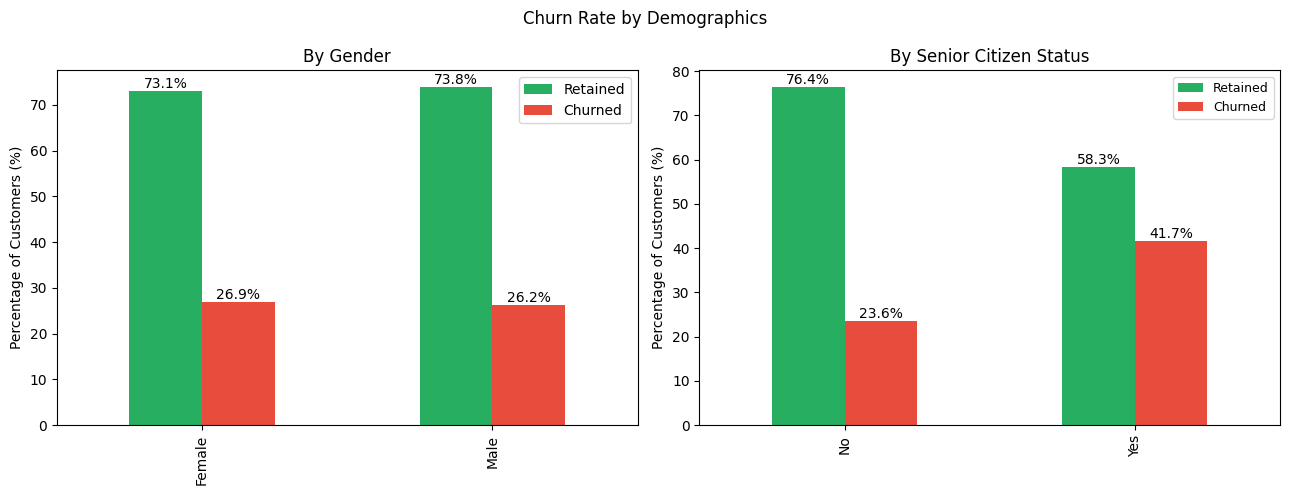

In [6]:
# Demographics: Churn by gender + senior citizen
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Churn Rate by Demographics')

# Gender
gender_df = df.groupby(['gender', 'churn']).size().unstack(fill_value=0)
gender_pct = gender_df.div(gender_df.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[0], color=['#27ae60', '#e74c3c'])
axes[0].set_title('By Gender')
axes[0].set_xlabel('')
axes[0].set_ylabel('Percentage of Customers (%)')
axes[0].legend(['Retained', 'Churned'])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%')

# Senior Citizen
senior_df = df.groupby(['seniorcitizen', 'churn']).size().unstack(fill_value=0)
senior_pct = senior_df.div(senior_df.sum(axis=1), axis=0) * 100
senior_pct.plot(kind='bar', ax=axes[1], color=['#27ae60', '#e74c3c'])
axes[1].set_title('By Senior Citizen Status')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage of Customers (%)')
axes[1].legend(['Retained', 'Churned'], fontsize=9)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

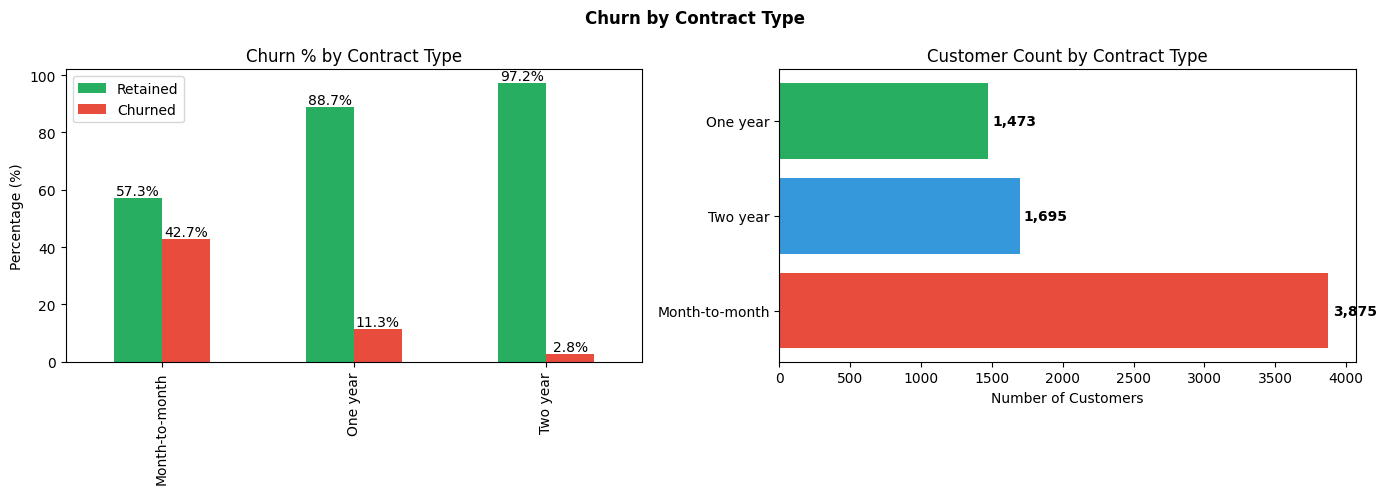

In [7]:
# Churn by Contract Type
contract_df = df.groupby(['contract', 'churn']).size().unstack(fill_value=0)
contract_pct = contract_df.div(contract_df.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn by Contract Type', fontweight= 'bold')

# Stacked bar
contract_pct.plot(kind='bar', ax=axes[0], color=['#27ae60', '#e74c3c'])
axes[0].set_title('Churn % by Contract Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].legend(['Retained', 'Churned'])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%')

# Customer count per contract
contract_counts = df['contract'].value_counts()
bars = axes[1].barh(contract_counts.index, contract_counts.values,
                    color=['#e74c3c', '#3498db', '#27ae60'])
axes[1].set_title('Customer Count by Contract Type')
axes[1].set_xlabel('Number of Customers')
for bar, val in zip(bars, contract_counts.values):
    axes[1].text(val + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

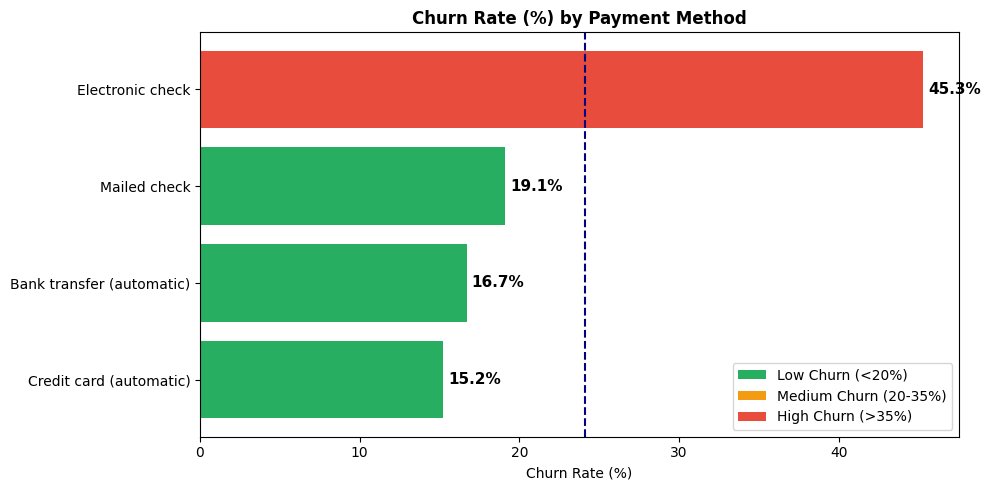

In [19]:
# Churn by Payment Method
payment_churn_sorted = payment_churn.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if v < 20 else '#f39c12' if v < 35 else '#e74c3c'
          for v in payment_churn_sorted.values]
bars = ax.barh(payment_churn_sorted.index, payment_churn_sorted.values,
               color=colors)

for bar, val in zip(bars, payment_churn_sorted.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Low Churn (<20%)'),
    Patch(facecolor='#f39c12', label='Medium Churn (20-35%)'),
    Patch(facecolor='#e74c3c', label='High Churn (>35%)')
]
ax.set_title('Churn Rate (%) by Payment Method',fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.legend(handles=legend_elements, loc='lower right')
ax.axvline(payment_churn.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Average: {payment_churn.mean():.1f}%')

plt.tight_layout()
plt.show()

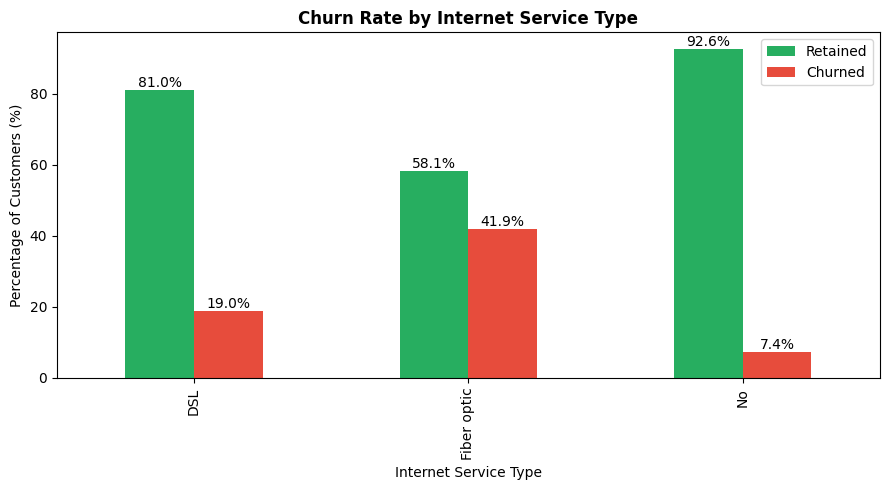

In [14]:
# Churn by internet services
internet_df = df.groupby(['internetservice', 'churn']).size().unstack(fill_value=0)
internet_pct = internet_df.div(internet_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
internet_pct.plot(kind='bar', ax=ax, color=['#27ae60', '#e74c3c'])
ax.set_title('Churn Rate by Internet Service Type',fontweight='bold')
ax.set_xlabel('Internet Service Type')
ax.set_ylabel('Percentage of Customers (%)')
ax.legend(['Retained', 'Churned'], fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()